centrality
- Degree
- Betweenness
- Pagerank
- CI

## MultiStage mind_wrapper

### Stage 1: Preprocess


### Stage 2: Dismantling

In [2]:
import igraph as ig
import torch
from copy import deepcopy
from typing import Callable,Dict
import numpy as np
import os
from task_encoder import TaskEncoder
from networks.dismantle import load_sac_dismantler,load_sac_dismantler_with_film, DQNPolicy, load_dqn_dismantler
import utils
import importlib
import baseline
importlib.reload(utils)
importlib.reload(baseline)
from baseline import ensure_attribute
from test import mind_dismantling
  
# def mind_warpper(graph:ig.Graph,ckpt_pth=None,gnn='mind',**kwargs):
#     '''
#     same return with preprocess
#     removals: complete solution
#     removed_sizes: cumulative removed number at each step, start from 0
#     lcc_sizes: lcc size at each step, len(lcc_sizes) = len(removed_sizes)
#     '''
#     graph = deepcopy(graph)
#     ensure_attribute(graph)
    
#     # defalut value when no args.config
#     # device: str='cuda:0'
#     device = torch.device('cpu')
#     F = 16; H = 4; K = 6
#     gnn = 'mind'

#     from utils.validate import validate_one_graph
    
#     if 'sac' in ckpt_pth:
#         policy, _, _, _, _ = load_sac_dismantler(F, H, K, gnn, device, ckpt_pth)
#         auc, robustness, _, removals = validate_one_graph(graph,policy=policy,log_removals=True)
#     else:
#         qf, _ = load_dqn_dismantler(F, H, K, gnn, device, ckpt_pth)
#         policy = DQNPolicy(qf)
#         auc, robustness, _, removals = validate_one_graph(graph,policy=policy,log_removals=True)
        
    
#     return auc, robustness, removals


from utils.common import load_g
G = load_g("graphs/simple/simple_100.pkl",name="test")
test_auc, test_robustness, test_removals = mind_dismantling(
    G,
    ckpt_pth = 'saved/mind/mind.ckpt',
    # ckpt_pth = 'saved/gcn/sac_20260309_111018/13999.ckpt',
    # ckpt_pth = 'saved/graphsage/dqn_20260316_183559/11999.ckpt',
    # ckpt_pth= 'saved/hgnn_v4/sac_graph_task_frozen_film_20260130_191042/13999.ckpt',
    step_ratio = 0
)


import baseline
import importlib
importlib.reload(baseline)
from baseline import evaluate_sol
test_auc, test_robustness, lcc_sizes, removed_sizes = evaluate_sol(G,test_removals)
print(test_auc,test_robustness)
print(len(lcc_sizes),len(removed_sizes))



Loaded graph test
Graph: test, AUC=0.479867, Robustness=0.475400, Steps=87
0.47986666666666666 0.4754
88 88


saved/mind/mind.ckpt
Loaded graph test
Graph: test, AUC=0.249148, Robustness=0.248687, Steps=330
saved/hgnn_v3/sac_teacher_betweenness_20260310_083133/24999.ckpt
Loaded graph test
Graph: test, AUC=0.232738, Robustness=0.232270, Steps=320
saved/graphsage/dqn_teacher_20260324_115255/14999.ckpt
Loaded graph test
Graph: test, AUC=0.268431, Robustness=0.267946, Steps=353
saved/gcn/dqn_20260317_014845/14999.ckpt
Loaded graph test
Graph: test, AUC=0.249182, Robustness=0.248716, Steps=355
saved/gcn/dqn_teacher_20260322_162759/19999.ckpt
Loaded graph test
Graph: test, AUC=0.296620, Robustness=0.296150, Steps=403
saved/gcn/dqn_teacher_20260322_190135/17999.ckpt
Loaded graph test
Graph: test, AUC=0.261056, Robustness=0.260603, Steps=367
saved/gcn/dqn_teacher_20260322_202521/14999.ckpt
Loaded graph test
Graph: test, AUC=0.334033, Robustness=0.333571, Steps=468
saved/gcn/sac_20260316_144026/19999.ckpt
Loaded graph test
Graph: test, AUC=0.262215, Robustness=0.261761, Steps=384
saved/graphsage/dqn_20

IndexError: list index out of range

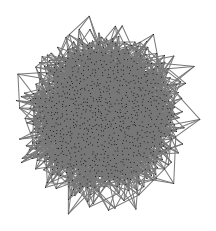

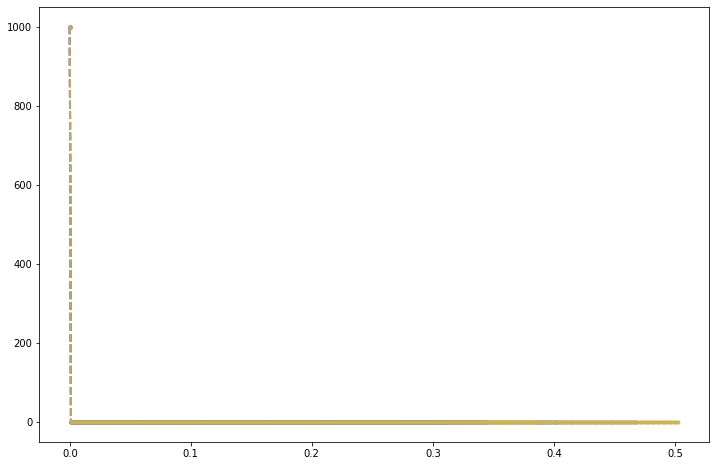

In [27]:
import igraph as ig
import os
import importlib
import baseline
import visualize_dismantling
importlib.reload(visualize_dismantling)
importlib.reload(baseline)
from utils import graph_models
importlib.reload(graph_models)
from utils.plot import plot_graph
from utils.common import load_g
from utils.graph_models import *
from baseline import baseline_dismantling,METHODS

# g = SBM(80,p_in=0.15,p_out=0.0075,num_blocks=2)
# g = SBM(96,p_in=0.12,p_out=0.01,num_blocks=3)
# g = SBM(200, p_in=0.2,p_out=0.01, num_blocks=2)
# g = DCSBM(120,p_in=0.3,p_out=0.01,num_blocks=5)
# g = ring_community(120,p_in=0.2,num_communities=4)
# g = star_community(120,p_in=0.15,num_communities=5)

# g = barbell(120,p_in=0.1,path_len=3,type="ER")


# g = WS(5000,k=4,p=0.3)
# g = ER(5000,p=0.001)
# g = LPA(5000,m=4,gamma=2.5)
# g = BA(1000,m=4)
with open('graphs/test/BA_n_1000_m_4.pkl','wb') as f:
    pickle.dump(g,f)

# g = load_g('graphs/test/BA_n_1000_m_5.pkl',name='test')
# g = load_g('graphs/test/ER_n_500_p_0.015.pkl',name='test')
# g = load_g('graphs/test/ER_n_1000_p_0.005.pkl',name='test')
# g = load_g('graphs/test/WS_n_500_k_4_p_0.3.pkl',name='test')
# g = load_g('graphs/test/WS_n_1000_k_4_p_0.3.pkl',name='test')

g['name'] = 'test'
g = g.subgraph(max(g.connected_components(), key=len)) 
plot_graph(g)

all_results = {}
compare_mind_ckpts = [
                    'saved/mind/mind.ckpt',
                    'saved/hgnn_v3/sac_teacher_betweenness_20260310_083133/24999.ckpt',
                    'saved/graphsage/dqn_teacher_20260324_115255/14999.ckpt',
                    'saved/gcn/dqn_20260317_014845/14999.ckpt', #GCN DQN 
                    'saved/gcn/dqn_teacher_20260322_162759/19999.ckpt', #GCN DQN None
                    'saved/gcn/dqn_teacher_20260322_190135/17999.ckpt', #GCN DQN PRE
                    'saved/gcn/dqn_teacher_20260322_202521/14999.ckpt', #GCN DQN PRE+RS*0.1(训练时间不足..) 
                    'saved/gcn/sac_20260316_144026/19999.ckpt', #GCN SAC
                    'saved/graphsage/dqn_20260316_183559/24999.ckpt', #GraphSAGE DQN
                    'saved/graphsage/dqn_teacher_20260316_194430/23999.ckpt', #GraphSAGE DQN PRE
                    'saved/graphsage/sac_20260316_144118/16999.ckpt', #GraphSAGE SAC
                    'saved/graphsage/sac_teacher_20260322_213146/13999.ckpt', #GraphSAGE SAC BC+RS
                    'saved/gat/sac_20260320_113356/7999.ckpt'
                    ]

for idx, ckpt_pth in enumerate(compare_mind_ckpts):
    print(ckpt_pth)
    gnn = ckpt_pth.split("/")[1]
    _, _, removals  = mind_dismantling(g,step_ratio=0.0,ckpt_pth=ckpt_pth)
    auc, r, lcc_sizes, removed_sizes = evaluate_sol(g,removals,threshold=0.1)
    method_name = ckpt_pth.split("/",1)[-1]
    all_results[method_name] = {
        'removals': removals,
        'auc': auc,
        'robustness': r,
        'lcc_sizes': lcc_sizes,
        'removed_sizes': removed_sizes,
        # 'lambda_list': lambda_list,
    }

from baseline import baseline_dismantling,METHODS
methods = {
    # "Spectral":METHODS['Spectral'],
    "Degree":METHODS['Degree'],
    # "Betweenness":METHODS['Betweenness'],
    "CI": METHODS['CI'],
    # "PageRank":METHODS['PageRank'],
    # "CoreHD":METHODS['CoreHD'],
    # "FINDER":METHODS['FINDER'],
    # "GDM":METHODS['GDM'],
    # "CoreGDM":METHODS['CoreGDM'],
    # "DomiRank":METHODS['DomiRank'],
    # "TSAM":METHODS['TSAM'],
    # "NIRM":METHODS['NIRM'],
    # "GND":METHODS['GND'],
    # "MinSum":METHODS["MinSum"]
}
baseline_results = baseline_dismantling(g,methods,visualize=False,threshold=0.1)
all_results.update(baseline_results)

from visualize_dismantling import visualize_multiple_curve
visualize_multiple_curve(g,all_results)

### compare mind_wrapper models

mind
Loaded graph test
Graph: test, AUC=27.502778, Robustness=0.225486, Steps=49
sac_teacher_20260129_163549
Loaded graph test
Graph: test, AUC=27.275000, Robustness=0.223472, Steps=47
sac_teacher_betweenness_20260309_210139
Loaded graph test
Graph: test, AUC=25.811111, Robustness=0.211250, Steps=46
method Betweenness: AUC=24.302778, Robustness=0.207361


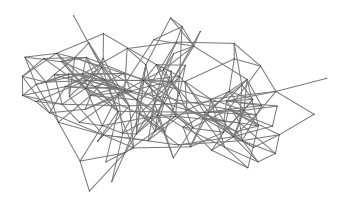

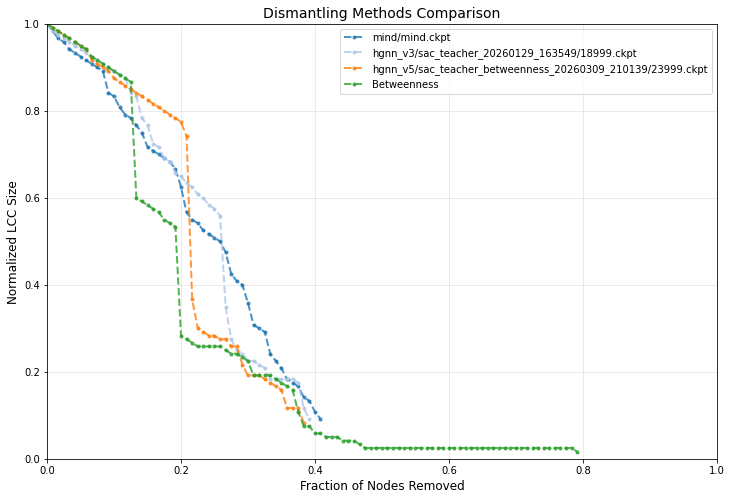

In [12]:
import igraph as ig
import os
import importlib
import baseline
import visualize_dismantling
importlib.reload(visualize_dismantling)
importlib.reload(baseline)
from utils import graph_models
importlib.reload(graph_models)
from utils.plot import plot_graph
from utils.common import load_g
from utils.graph_models import *
from baseline import baseline_dismantling,METHODS

g = SBM(80,p_in=0.15,p_out=0.0075,num_blocks=2)
g = SBM(120,p_in=0.12,p_out=0.007,num_blocks=3)
# g = SBM(200, p_in=0.3,p_out=0.01, num_blocks=2)
# g = DCSBM(120,p_in=0.3,p_out=0.01,num_blocks=5)
# g = ring_community(120,p_in=0.2,num_communities=4)
# g = star_community(120,p_in=0.15,num_communities=5)
# g = WS(80, k=8, p=0.5)
# g = barbell(120,p_in=0.1,path_len=3,type="ER")
# g = ER(80,0.2)
# g = BA(160,m=5)

g['name'] = 'test'
g = g.subgraph(max(g.connected_components(), key=len)) 
plot_graph(g)

all_results = {}
compare_mind_ckpts = [
                    'saved/mind/mind.ckpt',
                    # 'saved/finetune_prior_20260105_220540/2999.ckpt',
                    # 'saved/finetune_prior_20260106_075408/1999.ckpt',
                    # "saved/finetune_prior_20260106_151735/4799.ckpt", 
                    # "saved/finetune_prior_20260106_183209/4799.ckpt",
                    # "saved/finetune_prior_20260107_113306/5799.ckpt",
                    # "saved/finetune_prior_20260107_225616/5799.ckpt",
                    # "saved/finetune_20260107_163012/5799.ckpt",
                    # "saved/finetune_20260108_100547/5799.ckpt",
                    # "saved/finetune_prior_20260108_214004/6999.ckpt",
                    # "saved/finetune_prior_20260108_213417/19999.ckpt",
                    # "saved/finetune_prior_20260109_170406/9999.ckpt",
                    # "saved/finetune_prior_20260110_091248/13999.ckpt",
                    # "saved/finetune_prior_20260110_214344/13199.ckpt",
                    # "saved/finetune_prior_20260111_112035/5599.ckpt",
                    # "saved/finetune_prior_20260112_080602/8199.ckpt",
                    # "saved/mind/finetune_prior_20260112_113700/13799.ckpt",
                    # "saved/hgnn_v2/finetune_prior_20260120_200915/19999.ckpt",
                    # "saved/mind/finetune_prior_20260121_113317/19999.ckpt",
                    # "saved/hgnn_v3/finetune_prior_20260121_203959/17399.ckpt",
                    # "saved/hgnn_v3/sac_teacher_20260129_163549/18999.ckpt",
                    # "saved/hgnn_v4/sac_graph_task_ewc_film_20260201_230504/14999.ckpt",
                    # "saved/hgnn_v4/sac_graph_task_frozen_film_20260130_191042/13999.ckpt",
                    # 'saved/hgnn_v4/sac_20260215_222948/10999.ckpt',
                    # 'saved/hgnn_v4/sac_teacher_betweenness_20260215_235236/13999.ckpt',
                    'saved/hgnn_v3/sac_teacher_20260129_163549/18999.ckpt',
                    # 'saved/hgnn_v4/sac_20260216_102427/53999.ckpt',
                    'saved/hgnn_v5/sac_teacher_betweenness_20260309_210139/23999.ckpt'

                    ]

for idx, ckpt_pth in enumerate(compare_mind_ckpts):
    _, _, test_removals  = mind_wrapper(g,step_ratio=0.0,ckpt_pth=ckpt_pth)
    method_name = ckpt_pth.split("/",1)[-1]
    all_results[method_name] = test_removals

from baseline import baseline_dismantling,METHODS
methods = {
    # "Spectral":METHODS['Spectral'],
    # "Degree":METHODS['Degree'],
    "Betweenness":METHODS['Betweenness'],
    # "BetweennessNA":METHODS['BetweennessNA'],
    # "CI": METHODS['CI'],
    # 'FINDER':METHODS['FINDER']
}
baseline_results = baseline_dismantling(g,methods,visualize=False)
all_results.update(baseline_results)

from visualize_dismantling import visualize_multiple_curve
visualize_multiple_curve(g,all_results)

graphs/real/bio/foodweb-baywet.pkl 128
   Num_nodes  Num_edges  AvgDegree  Diam  AvgShortPath  Clustering Coffe  \
0      128.0     2075.0  32.421875   3.0      1.776329          0.334622   

          r         Q  
0 -0.111663  0.181047  
Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 48/48 [00:00<00:00, 3006.62it/s]

Loaded graph graphs/real/bio/foodweb-baywet.pkl


Graph: graphs/real/bio/foodweb-baywet.pkl, AUC=0.396637, Robustness=0.393127, Steps=90
Loaded graph graphs/real/bio/foodweb-baywet.pkl
Graph: graphs/real/bio/foodweb-baywet.pkl, AUC=0.357198, Robustness=0.353577, Steps=74
method Degree: AUC=0.378123, Robustness=0.374573, runtime=0.081835


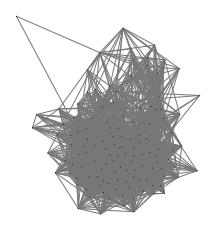

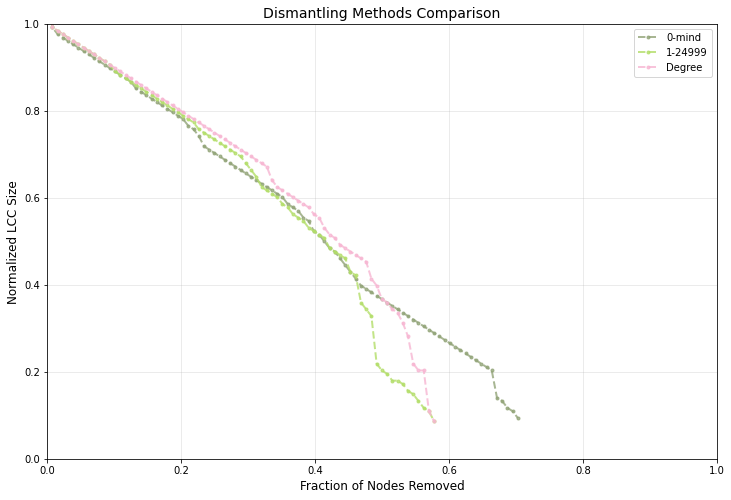

In [9]:
import matplotlib.pyplot as plt
import os
import importlib
import utils
import visualize_dismantling
import baseline
importlib.reload(utils)
importlib.reload(visualize_dismantling)
importlib.reload(baseline)
from utils.common import load_g
from utils.graph_models import statistics
from utils.plot import plot_graph
from utils.structural_diversity_analysis import analyze_powerlaw
# g_name = 'graphs/real/bio/.pkl'


g_name = 'graphs/real/bio/foodweb-baywet.pkl'
# g_name = 'graphs/real/bio/foodweb-baydry.pkl'
# g_name = 'graphs/real/bio/maayan-foodweb.pkl'
# g_name = 'graphs/real/bio/dimacs10-celegansneural.pkl'
# g_name = 'graphs/real/bio/arenas-meta.pkl'
# g_name = 'graphs/real/bio/maayan-Stelzl.pkl'
# g_name = 'graphs/real/bio/moreno_propro.pkl'
# g_name = 'graphs/real/bio/maayan-figeys.pkl'
# g_name = 'graphs/real/bio/maayan-vidal.pkl'

# g_name = 'graphs/real/social/librec-filmtrust-trust.pkl'
# g_name = 'graphs/real/social/opsahl-ucsocial.pkl'
# g_name = 'graphs/real/social/petster-hamster.pkl'
# g_name = 'graphs/real/social/librec-ciaodvd-trust.pkl'
# g_name = 'graphs/real/social/advogato.pkl'
# g_name = 'graphs/real/social/pajek-erdos.pkl'
# g_name = 'graphs/real/social/ego-twitter.pkl'
# g_name = 'graphs/real/social/munmun_digg_reply_LCC.pkl'

# g_name = 'graphs/real/information/econ-wm1.pkl'
# g_name = 'graphs/real/information/dimacs10-polblogs.pkl'
# g_name = 'graphs/real/information/web-EPA.pkl'
# g_name = 'graphs/real/information/subelj_jung-j_jung-j.pkl'
# g_name = 'graphs/real/information/subelj_jdk_jdk.pkl'
# g_name = 'graphs/real/information/p2p-Gnutella06.pkl'
# g_name = 'graphs/real/information/dblp-cite.pkl'

# g_name = 'graphs/real/tech/london_transport_multiplex_aggr.pkl'
# g_name = 'graphs/real/tech/eu-powergrid.pkl'
# g_name = 'graphs/real/tech/opsahl-openflights.pkl'
# g_name = 'graphs/real/tech/gridkit-eupowergrid.pkl'
# g_name = 'graphs/real/tech/gridkit-north_america.pkl'
# g_name = 'graphs/real/tech/internet-topology.pkl'

# g_name = 'graphs/gen/citeseer.pkl'
# g_name = 'graphs/gen/cora.pkl'
# g_name = 'graphs/gen/ego-facebook.pkl'

g = load_g(g_name,name=g_name)
print(g['name'],g.vcount())

# g_lcc = g.subgraph(max(g.connected_components(), key=len))
g_lcc = g.connected_components().giant()
plot_graph(g_lcc)
print(statistics(g_lcc))
analyze_powerlaw(g_lcc)

all_results = {}
compare_mind_ckpts = [
                    'saved/mind/mind.ckpt',
                    # 'saved/hgnn_v3/sac_teacher_20260129_163549/18999.ckpt',
                    # 'saved/hgnn_v4/sac_20260216_102427/53999.ckpt',
                    # 'saved/hgnn_v4/sac_teacher_betweenness_20260201_151201/40999.ckpt',
                    # 'saved/hgnn_v5/sac_teacher_betweenness_20260309_210139/23999.ckpt',
                    'saved/hgnn_v3/sac_teacher_betweenness_20260310_083133/24999.ckpt'
                    ]

for idx, ckpt_pth in enumerate(compare_mind_ckpts):
    gnn = ckpt_pth.split("/")[1]
    _, _, removals  = mind_dismantling(g_lcc,step_ratio=0.0,ckpt_pth=ckpt_pth)
    method_name = str(idx)+ '-' + os.path.basename(ckpt_pth).replace('.ckpt', '')
    auc, r, lcc_sizes, removed_sizes = evaluate_sol(g_lcc,removals,threshold=0.1)
    all_results[method_name] = {
        'removals': removals,
        'auc': auc,
        'robustness': r,
        'lcc_sizes': lcc_sizes,
        'removed_sizes': removed_sizes,
        # 'lambda_list': lambda_list,
    }

from baseline import baseline_dismantling,METHODS
methods = {
    # "Spectral":METHODS['Spectral'],
    # "Random":METHODS['Random'],
    "Degree":METHODS['Degree'],
    # "Betweenness":METHODS['Betweenness'],
    # "CI": METHODS['CI'],
    # "PageRank":METHODS['PageRank'],
    # "CoreHD":METHODS['CoreHD'],
    # "MinSum":METHODS['MinSum'],
    # 'FINDER':METHODS['FINDER']
}
baseline_results = baseline_dismantling(g_lcc,methods,threshold=0.1,visualize=False)
all_results.update(baseline_results)

from visualize_dismantling import visualize_multiple_curve
visualize_multiple_curve(g_lcc,all_results)

# baselines

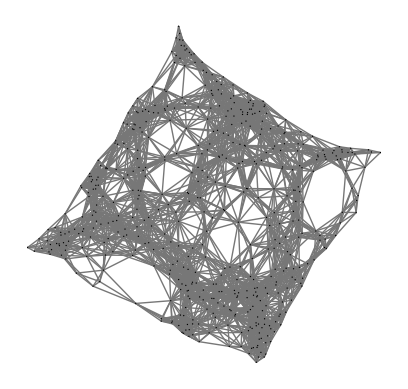

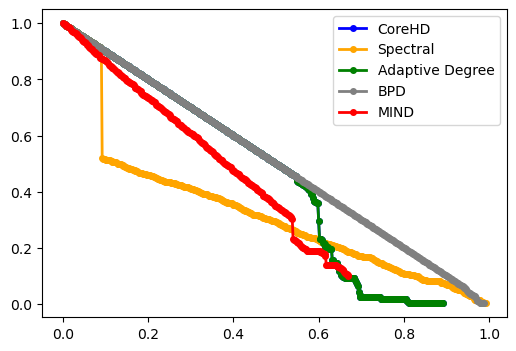

{}

In [ ]:
# Setup SBM
# Generate a 2D Random Geometric Graph
# n=500 nodes, radius=0.12 (threshold for connectivity)
G_rgg = ig.Graph.GRG(n=500, radius=0.12)
G_rgg.vs['static_id'] =list(range(G_rgg.vcount())) 
plot_graph(G_rgg)
benchmark_dismantling(G_rgg, methods)